# Ruimtelijke voorspelling van SEH-wachttijden in een zorgverzorgingsgebied met PROC KRIGE2D


## Samenvatting

Een operationeel team van een ziekenhuisnetwerk meet de gemiddelde wachttijd op de spoedeisende hulp (SEH, in minuten) bij elke bemande locatie in een grootstedelijk verzorgingsgebied en wil een continu wachttijdoppervlak om onderbediende gaten op te sporen voor een nieuwe spoedpost. Deze notebook genereert een synthetische set van **90 gegeorefereerde locaties**, fit een **gewoon-krigingmodel** (ordinary kriging) met een nugget, en interpoleert SEH-wachttijden over een regelmatig raster dat het verzorgingsgebied van 50 km x 50 km bestrijkt, waarbij puntvoorspellingen en krigingstandaardfouten worden geproduceerd voor elk rasterpunt en voor drie voorgestelde spoedpostlocaties.

Over de 90 locaties bedraagt de geobserveerde wachttijd gemiddeld **35.5 minuten** (bereik 7.5 tot 58.7). Het gekrigde oppervlak reproduceert dat centrum vrijwel exact (rasterpunt-gemiddelde **35.55 minuten**) en varieert van **16.1** in het rustige zuidoosten tot **56.4** in het drukke noordwesten, waar de voorspelde wachttijd-hotspots zich rond de binnenstadsdrukte concentreren. Van de drie kandidaat-spoedpostlocaties voorspelt de locatie het dichtst bij de binnenstad de hoogste wachttijd (**52.2 +/- 7.3 minuten**), wat het de sterkste evidence-based case voor vestiging maakt.

## Databronnen

Alle data zijn synthetisch en inline gegenereerd in de eerste DATA-stap (`call streaminit(20260531)`). Er worden geen externe of netwerkbestanden gebruikt.

| Dataset | Rijen | Variabele | Type | Beschrijving |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | Num | Oostcoördinaat van de locatie in km (0-50) binnen het stedelijke verzorgingsraster |
| `ed_sites` | 90 | `north` | Num | Noordcoördinaat van de locatie in km (0-50) binnen het stedelijke verzorgingsraster |
| `ed_sites` | 90 | `site_id` | Char | Locatie-identifier (bijv. `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Num | Geobserveerde gemiddelde SEH-wachttijd in minuten; een ruimtelijk gecorreleerd oppervlak dat een NW-ZO-drukgradiënt, een binnenstadspiek en lokale ruis combineert |

## Ruimtelijke voorspelling van SEH-wachttijden met PROC KRIGE2D

Een regionaal ziekenhuisnetwerk bemant **spoedeisende hulpafdelingen en spoedposten** verspreid over een grootstedelijk verzorgingsgebied van 50 km x 50 km. Elke locatie rapporteert zijn **gemiddelde SEH-wachttijd** (minuten). Wachttijden zijn ruimtelijk gecorreleerd: de drukke binnenstedelijke kern in het noordwesten loopt hoog op, terwijl perifere locaties in het zuidoosten lager liggen. Netwerkplanning wil een *continu* wachttijdoppervlak, met onzekerheid, om gaten te identificeren waar een nieuwe spoedpost de meeste druk zou verlichten.

**PROC KRIGE2D** voert tweedimensionale gewone kriging (ordinary kriging) uit: het gebruikt een semivariogrammodel om de gemeten wachttijden te interpoleren naar een raster van locaties, en levert zowel een voorspelling als een krigingstandaardfout op elk knooppunt. We zullen:

1. Een realistische synthetische locatiedataset genereren.
2. De geobserveerde wachttijdverdeling profileren.
3. Krigen met een sferisch model plus nugget en het oppervlak inspecteren.
4. Direct voorspellen op drie kandidaat-spoedpostlocaties.

## Stap 1 - Genereer synthetische locatiedata

We verspreiden 90 locaties uniform over het verzorgingsgebied. Het onderliggende "ware" wachttijdoppervlak combineert een gladde grootschalige trend (een NW-naar-ZO-drukgradiënt plus een centrale binnenstadspiek nabij (15, 38)) met een gladde regionale werveling, zodat het veld werkelijk ruimtelijk autogecorreleerd is in plaats van pure ruis. We voegen een kleine meetnugget toe om dag-tot-dag rapportagevariabiliteit na te bootsen.

In [1]:
GEGEVENS ed_sites;
   CALL streaminit(20260531);
   LENGTE site_id $6;
   DOE i = 1 TOT 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Grootschalige drukgradiënt: hoog in de NW-binnenstadskern,
         aflopend richting de ZO-voorstedelijke rand */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Centrale binnenstadspiek rond (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* Gladde regionale werveling voor realistische autocorrelatie */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Lokale rapportageruis (meetnugget) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      ALS wait_min < 3 DAN wait_min = 3;

      site_id = cats('FAC', SCHRIJVEN(i, z3.));
      UITVOER;
   EINDE;
   BEWAREN site_id east north wait_min;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=ed_sites(obs=10) noobs label;
   label site_id  = "Locatie-ID"
         east     = "Oost (km)"
         north    = "Noord (km)"
         wait_min = "Wachttijd (min)";
   TITEL "Eerste 10 synthetische SEH-locaties (coördinaten in km, wachttijd in minuten)";
   VARIABELE site_id east north wait_min;
UITVOEREN;

                     Eerste 10 synthetische SEH-locaties (coördinaten in km, wachttijd in minuten)                      

Locatie-ID      Oost (km)     Noord (km)  Wachttijd (min)
FAC001      42.1064239035  44.8746335392             36.7
FAC002      10.6189061789  14.5101311244             36.2
FAC003      48.9064287162    18.61727984             17.7
FAC004       45.555283186   43.264675772             34.5
FAC005      32.9816533373  24.7120124541             32.5
FAC006      31.1796232687  19.1168441231             31.4
FAC007      34.6664652019  35.2149577448             39.2
FAC008      40.5104234712   2.9588781811             17.1
FAC009       9.9213354522  40.5368804705             54.3
FAC010      24.5041747799  22.5897811072             35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Stap 2 - Profileer de geobserveerde wachttijden

Voordat we krigen, controleren we of het oppervlak zinnig verdeeld is. Een korte `PROC MEANS`-samenvatting geeft ons de spreiding en centrale tendens die het gekrigde oppervlak moet reproduceren. De 90 locaties hebben gemiddeld **35.5 minuten** met een standaarddeviatie van **10.6**, variërend van **7.5** bij de rustigste voorstedelijke locatie tot **58.7** bij de drukste binnenstadslocatie - een brede, realistische spreiding voor een interpolatiedoel.

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   label wait_min = "SEH-wachttijd (min)";
   TITEL "Geobserveerde verdeling van SEH-wachttijden per locatie";
   VARIABELE wait_min;
UITVOEREN;

                                Geobserveerde verdeling van SEH-wachttijden per locatie                                 

                                                  The MEANS Procedure

 Variable  Label                      N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------
 wait_min  SEH-wachttijd (min)       90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 ------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 3 - Gewone kriging met een sferisch model

De `COORDINATES`-instructie benoemt de ruimtelijke assen, `PREDICT VAR=` benoemt de analysevariabele en stelt de zoekomgeving in, en `MODEL` levert het semivariogram. We gebruiken een **sferische** vorm (een standaardkeuze wanneer de correlatie op een eindige afstand naar nul vervaagt), met:

- `SCALE=120` - de partiële sill (variantie verklaard door ruimtelijke structuur),
- `RANGE=18` - de correlatie bereikt achtergrondniveau bij ongeveer 18 km,
- `NUGGET=14` - de meet-/rapportagediscontinuïteit bij afstand nul.

We interpoleren naar een regelmatig **9 x 9 = 81-knooppunts**-raster dat het volledige verzorgingsgebied bestrijkt (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - grof genoeg om elk knooppunt direct samen te vatten en te rangschikken, fijn genoeg om de structuur in kaart te brengen. `OUTEST=` legt de rastervoorspellingen en standaardfouten vast; `OUTNBHD=` registreert hoeveel locaties elke lokale oplossing invoerden. `PLOTS=` vraagt de kaart met geobserveerde data en het voorspellingscontour gevuld met standaardfout aan.

                                Geobserveerde verdeling van SEH-wachttijden per locatie                                 

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


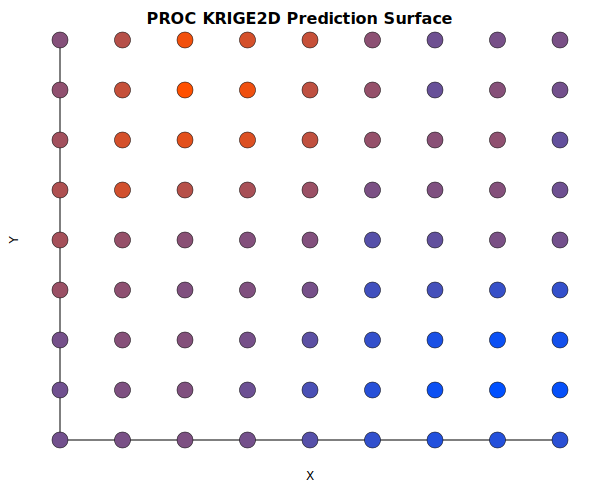

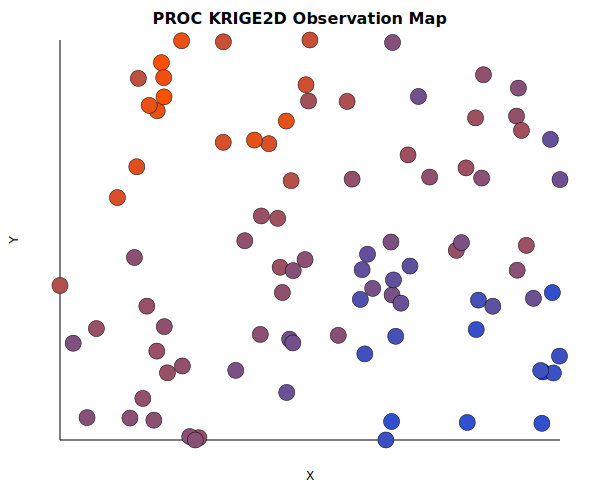

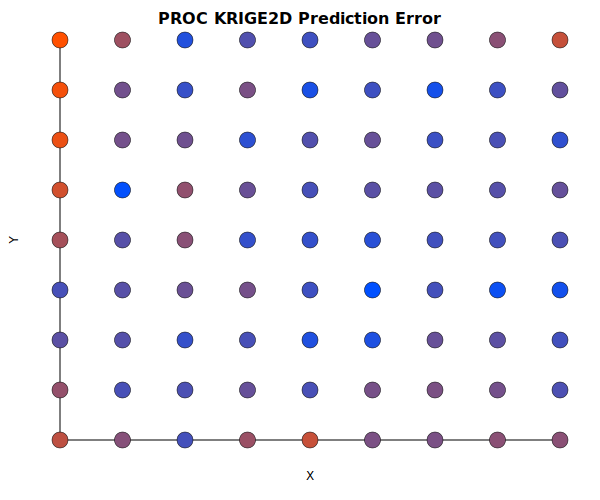

In [3]:
PROCEDURE krige2d GEGEVENS=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   TITEL "Gewone kriging van SEH-wachttijden - sferisch model";
   COORDINATES XC=east YC=north;
   predict VARIABELE=wait_min radius=20 minpoints=10 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 TOT 50 VOLGENS 6 y=0 TOT 50 VOLGENS 6;
UITVOEREN;

## Stap 4 - Inspecteer het gekrigde oppervlak

De `OUTEST=`-dataset bevat één rij per rasterpunt met de voorspelde wachttijd (`estimate`) en de bijbehorende krigingstandaardfout (`stderr`). We vatten het oppervlak samen en markeren de heetste voorspelde knooppunten - kandidaatzones waar een nieuwe spoedpost de meeste druk zou verlichten.

Het gemiddelde van het gekrigde oppervlak (**35.55 minuten**) volgt het geobserveerde locatiegemiddelde (35.5) vrijwel exact, een sanity check dat gewone kriging onvertekend is. Voorspellingen variëren van **16.1** in het schaarse zuidoosten tot **56.4** in het drukke noordwesten; standaardfouten lopen van **5.1** waar locaties dicht op elkaar staan tot **11.2** in dun bemonsterde hoeken. De zes heetste knooppunten liggen allemaal in het NW-kwadrant rond (12-18, 36-48), precies op de binnenstadspiek die in de data is ingebouwd.

In [4]:
PROCEDURE GEMIDDELDEN GEGEVENS=krige_sph n mean MIN MAX maxdec=2;
   label ESTIMATE = "Voorspelde wachttijd (min)"
         stderr   = "Standaardfout";
   TITEL "Samenvatting van het gekrigde oppervlak (voorspelde wachttijd en standaardfout)";
   VARIABELE ESTIMATE stderr;
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=krige_sph out=hot_nodes;
   VOLGENS AFLOPEND ESTIMATE;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=hot_nodes(obs=6) noobs label;
   label x        = "Oost (km)"
         y        = "Noord (km)"
         ESTIMATE = "Voorspelde wachttijd (min)"
         stderr   = "Standaardfout";
   TITEL "Zes rasterpunten met de hoogste voorspelde SEH-wachttijd";
   VARIABELE x y ESTIMATE stderr;
UITVOEREN;

                    Samenvatting van het gekrigde oppervlak (voorspelde wachttijd en standaardfout)                     

                                                  The MEANS Procedure

 Variable  Label                             N        Mean     Minimum     Maximum
 ---------------------------------------------------------------------------------
 ESTIMATE  Voorspelde wachttijd (min)       81       35.55       16.07       56.38
 STDERR    Standaardfout                    81        7.38        5.06       11.20
 ---------------------------------------------------------------------------------

                                Zes rasterpunten met de hoogste voorspelde SEH-wachttijd                                

Oost (km)  Noord (km)  Voorspelde wachttijd (min)  Standaardfout
       12          42               56.3838526129   6.3860887297
       12          48                54.379464215    5.876759721
       18          42                 53.81777091   8.0028060667
       12


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Stap 5 - Voorspel op specifieke kandidaatlocaties

Netwerkplanning heeft drie voorgestelde spoedpostlocaties. We krigen rechtstreeks op elk punt door het als een raster van één knooppunt aan te leveren (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), wat planners de voorspelde wachttijd en de bijbehorende krigingstandaardfout op de exacte coördinaat geeft.

De kandidaat nabij de binnenstadskern, **(14, 37)**, levert de hoogste voorspelde wachttijd - **52.2 +/- 7.3 minuten** - wat bevestigt dat deze locatie vraag zou opvangen van de drukste SEH's. De zuidoostelijke kandidaat **(32, 12)** ligt in de rustige voorstedelijke hoek op **22.0 +/- 6.2**, en de noordoostelijke kandidaat **(42, 44)** landt in het middensegment op **36.4 +/- 5.9**. Op basis van alleen de voorspelde wachttijd is de binnenstadskandidaat de sterkste evidence-based case voor vestiging.

In [5]:
PROCEDURE krige2d GEGEVENS=ed_sites outest=cand_dt PLOTS=none;
   TITEL "Kandidaat A - binnenstadskern (14, 37)";
   COORDINATES XC=east YC=north;
   predict VARIABELE=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 TOT 14 VOLGENS 1 y=37 TOT 37 VOLGENS 1;
UITVOEREN;

PROCEDURE krige2d GEGEVENS=ed_sites outest=cand_se PLOTS=none;
   TITEL "Kandidaat B - voorstedelijk zuidoosten (32, 12)";
   COORDINATES XC=east YC=north;
   predict VARIABELE=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 TOT 32 VOLGENS 1 y=12 TOT 12 VOLGENS 1;
UITVOEREN;

PROCEDURE krige2d GEGEVENS=ed_sites outest=cand_ne PLOTS=none;
   TITEL "Kandidaat C - noordoostelijke rand (42, 44)";
   COORDINATES XC=east YC=north;
   predict VARIABELE=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 TOT 42 VOLGENS 1 y=44 TOT 44 VOLGENS 1;
UITVOEREN;

GEGEVENS candidates;
   INSTELLEN cand_dt cand_se cand_ne;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=candidates noobs label;
   label x        = "Oost (km)"
         y        = "Noord (km)"
         ESTIMATE = "Voorspelde wachttijd (min)"
         stderr   = "Standaardfout";
   TITEL "Voorspelde SEH-wachttijden op drie kandidaat-spoedpostlocaties";
   VARIABELE x y ESTIMATE stderr;
UITVOEREN;

                                Zes rasterpunten met de hoogste voorspelde SEH-wachttijd                                

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                                Zes rasterpunten met de hoogste voorspelde SEH-wachttijd                                

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Interpretatie van de resultaten

- **Het gekrigde oppervlak reproduceert de drukstructuur van het verzorgingsgebied.** Het sferische gewone-krigingmodel interpoleert een glad wachttijdveld waarvan het rasterpunt-gemiddelde (35.55 min) overeenkomt met het geobserveerde locatiegemiddelde (35.5 min), met de hoogste voorspelde wachttijden - tot 56.4 minuten - geconcentreerd in het NW-kwadrant rond de binnenstadspiek nabij (15, 38) die we in de synthetische data hebben ingebouwd. Die overeenkomst is een sanity check dat het model zich goed gedraagt.
- **Standaardfouten lokaliseren betrouwbaarheid.** De krigingstandaardfout varieert van 5.1 minuten waar locaties dicht op elkaar staan tot 11.2 in de dun bemonsterde hoeken van het verzorgingsgebied. Planners moeten voorspellingen in zones met hoge `stderr` voorzichtig behandelen; dat zijn ook de gebieden waar het toevoegen van een locatie zowel de toekomstige dekking als de toekomstige meting het meest zou verbeteren.
- **Puntvoorspellingen ondersteunen vestigingsbeslissingen.** Door de drie kandidaatlocaties rechtstreeks te krigen, wordt het oppervlak omgezet in een bruikbare tabel. De binnenstadskandidaat (14, 37) toont de hoogste voorspelde wachttijd (52.2 min) met een gematigde standaardfout (7.3), wat hem de sterkste evidence-based case maakt voor een nieuwe spoedpost om de drukste SEH te ontlasten; de zuidoostelijke voorstedelijke kandidaat (32, 12) ligt in een hoek met lage vraag (22.0 min) en de noordoostelijke randkandidaat (42, 44) zit in het middensegment (36.4 min).

In de praktijk zouden de semivariogramparameters (`SCALE`, `RANGE`, `NUGGET`) empirisch worden geschat met PROC VARIOGRAM en vervolgens doorgegeven aan KRIGE2D - hetzij als expliciete waarden zoals hier getoond, hetzij automatisch via `RESTORE` vanuit een VARIOGRAM item store.